# Set up

In [34]:
PATH_TO_DATA="data_files" #change based on working directory

# Import Libraries

In [35]:
import sys
sys.path.append('../')
from kairos.custom_valuations import *
from kairos.utils import *
from kairos.fixed_valuations import *

import opendataval
from opendataval.experiment import ExperimentMediator
from opendataval.dataval.api import DataEvaluator, ModelLessMixin
from opendataval.dataval import DataOob, LavaEvaluator, KNNShapley, DVRL
from opendataval.experiment import discover_corrupted_sample, noisy_detection
from opendataval.dataloader import Register, DataFetcher, mix_labels, add_gauss_noise
from opendataval.model import ClassifierMLP, LogisticRegression

import matplotlib.pyplot as plt
import numpy as np
import torch
import json
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# import importlib
# importlib.reload(kairos.custom_valuations)
# importlib.reload(kairos.utils)
# importlib.reload(kairos.fixed_valuations)

import pandas as pd
from sklearn.mixture import GaussianMixture
import ast
import time
from sklearn.metrics import roc_auc_score

In [36]:
markers = {
    'DataOob': 'o',
    'KNNShapley': 's',
    'FixedKNNShapley': 's',
    'FixedLavaEvaluator': 'x',
    'LavaEvaluator': 'x',
    'DVRL': 'x',
    'Kairos': '^',
}
def write_dict(d, fname):
    txt = json.dumps(d)
    with open(f'logs/{fname}.json', 'w+') as f:
        f.write(txt)

#train_count, valid_count, test_count = 10000, 300, 10000
train_kwargs = {"epochs": 3, "batch_size": 100, "lr": 0.01}
metric_name = 'accuracy'
#noise_rate = 0.2

In [37]:
def load_presplit_dataset(dataset_name, exp_num, data_frac, path_to_data, cache_dir=None, force_download=False):
        # Load CSVs into numpy arrays
        x_train = pd.read_csv(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/X_train_dirty.csv").values
        y_train = pd.read_csv(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/y_train_dirty.csv").values

        x_valid = pd.read_csv(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/X_val.csv").values
        y_valid = pd.read_csv(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/y_val.csv").values

        x_test = pd.read_csv(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/X_test.csv").values
        y_test = pd.read_csv(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/y_test.csv").values

        # Flatten labels to shape (N,)
        y_train = y_train.ravel().astype(int)
        y_valid = y_valid.ravel().astype(int)
        y_test  = y_test.ravel().astype(int)

        # Take subsets
        # np.random.seed(1)
        # n_train = np.random.choice(np.arange(len(x_train)), size=int(len(x_train) * data_frac), replace=False)#int(len(x_train) * data_frac)
        # n_valid = np.random.choice(np.arange(len(x_valid)), size=int(len(x_valid) * data_frac),  replace=False)#int(len(x_valid) * data_frac)
        # n_test  = np.random.choice(np.arange(len(x_test)), size=int(len(x_test) * data_frac),  replace=False)#int(len(x_test) * data_frac)
        print('len n train: ',len(x_train))

        n_train = len(x_train) - int(len(x_train) * data_frac)
        n_valid = int(len(x_valid) * data_frac)
        n_test  = int(len(x_test) * data_frac)


        x_train = x_train[n_train:]
        y_train = y_train[n_train:]

        x_valid = x_valid[:n_valid]
        y_valid = y_valid[:n_valid]

        x_test = x_test[:n_test]
        y_test = y_test[:n_test]

        num_classes = int(max(y_train.max(), y_valid.max(), y_test.max())) + 1

        # One-hot encode
        y_train = np.eye(num_classes)[y_train]
        y_valid = np.eye(num_classes)[y_valid]
        y_test  = np.eye(num_classes)[y_test]

        covariates = (x_train, x_valid, x_test)
        labels = (y_train, y_valid, y_test)

        # print(f"num_classes: {num_classes}")
        # print(f"y_train min/max: {y_train.min()}/{y_train.max()}")
        # print(f"y_train shape: {y_train.shape}")
        # print(f"Any labels >= num_classes? {(y_train >= num_classes).any()}")
        # print(f"Any NaN in y_train? {np.isnan(y_train).any()}")
        # print(f"Unique labels: {np.unique(y_train)}")

        return covariates, labels

### plot accuracy
def plot_valuations(eval_name, eval_med, fetcher, dataset_name, exp_num):

        evalu = None
        for evaluator in eval_med.data_evaluators:
                if evaluator.__class__.__name__ == eval_name:
                        evalu = evaluator
                        break

        if evalu is None:
                raise RuntimeError(f"{eval_name} evaluator not found in eval_med")
        
        if eval_name == 'LavaEvaluator':
               pretty_eval_name = 'Lava'
        else:
               pretty_eval_name = eval_name

        valuations = evalu.data_values  # length = n_train

        # Identify noisy vs clean indices
        noisy = np.array(fetcher.noisy_train_indices)
        clean = np.setdiff1d(np.arange(len(valuations)), noisy)

        vals_noisy = valuations[noisy]
        vals_clean = valuations[clean]
        print(len(vals_clean), len(vals_noisy))

        plt.figure(figsize=(6,5))

        # Option A: Histogram curves (what your example image uses)
        plt.hist(vals_clean, bins=50, density=True, histtype='step', linewidth=2, label="Clean", color='blue')
        plt.hist(vals_noisy, bins=50, density=True, histtype='step', linewidth=2, label="Noisy", color='red')

        # Option B: KDE smooth curves (optional)
        # from scipy.stats import gaussian_kde
        # xs = np.linspace(min(valuations), max(valuations), 500)
        # plt.plot(xs, gaussian_kde(vals_clean)(xs), label="Clean KDE", color='blue')
        # plt.plot(xs, gaussian_kde(vals_noisy)(xs), label="Noisy KDE", color='red')

        plt.xlabel(f"{pretty_eval_name} Valuation Score")
        plt.ylabel("Frequency (Density)")
        plt.title(f"{pretty_eval_name} {dataset_name} Valuations: Experiment {exp_num}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


def thresh_acc(eval_name, eval_med, dataset_name, exp_num, fetcher):
        evalu = None
        for evaluator in eval_med.data_evaluators:
            if evaluator.__class__.__name__ == eval_name:
                evalu = evaluator
                break

        if evalu is None:
            raise RuntimeError(f"{eval_name} evaluator not found in eval_med")

        valuations = evalu.data_values
        
        vals = valuations.reshape(-1,1)
        gmm = GaussianMixture(n_components=2, random_state=42).fit(vals)

        # responsibilities: P(component k | v_i)
        probs = gmm.predict_proba(vals)

        # Determine which component = noisy (lower mean)
        means = gmm.means_.reshape(-1)
        noisy_component = np.argmin(means)  

        # threshold = decision boundary between gaussians
        threshold = np.mean([
            means[noisy_component],
            means[1-noisy_component]
        ])
        
        print(f"{eval_name} {dataset_name} xperiment {exp_num}")
        print("GMM threshold:", round(threshold, 4))

        pred = (valuations < threshold).astype(int)  

        y_true = np.zeros(len(valuations), dtype=int)
        y_true[fetcher.noisy_train_indices] = 1  # 1 = real noisy

        accuracy = round((pred == y_true).mean(), 4)

        from sklearn.metrics import precision_score, recall_score, f1_score

        precision = round(precision_score(y_true, pred), 4)
        recall = round(recall_score(y_true, pred), 4)
        f1 = round(f1_score(y_true, pred), 4)

        # Use the probability that a point belongs to the noisy component
        noisy_prob = probs[:, noisy_component]

        auc = roc_auc_score(y_true, noisy_prob)
        auc = round(auc, 4)

        print("Accuracy:", accuracy)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 score:", f1)
        print("AUC:", auc)
        print('----------------------------------')

        return accuracy, precision, recall, f1, auc

In [38]:
def run_experiment(dataset_name, exp_num, data_frac, path_to_data):


    Register(
        dataset_name=f"{dataset_name}_experiment{exp_num}",
        one_hot=False,
        cacheable=False,
        presplit=True
    )(lambda: load_presplit_dataset(dataset_name, exp_num, data_frac, path_to_data))

    fetcher = DataFetcher(f"{dataset_name}_experiment{exp_num}")


    with open(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/noisy_indices.txt", 'r') as noise_file:
        noisy_indices = list(ast.literal_eval(noise_file.read()))

    # fetcher.noisy_train_indices = [i for i in noisy_indices if i < len(fetcher.x_train)]
    # curr_noisy_idxs_count = sum(np.array(fetcher.noisy_train_indices) < len(fetcher.x_train))

    # Calculate the offset (to deal with subsetting dataset and experiment 4 noisy data being all at the end)
    original_train_len = len(pd.read_csv(f"{path_to_data}/{dataset_name}/experiment_{exp_num}/X_train_dirty.csv"))
    n_train_offset = original_train_len - int(original_train_len * data_frac)
    
    # Adjust noisy indices: subtract offset and filter for valid range
    fetcher.noisy_train_indices = [
        i - n_train_offset 
        for i in noisy_indices 
        if i >= n_train_offset and i < original_train_len
    ]
    
    curr_noisy_idxs_count = len(fetcher.noisy_train_indices)




    # Estimate kernel bandwidth w/ median sample pairwise distance
    kairos = Kairos()
    kairos.input_data(fetcher.x_train, fetcher.y_train, fetcher.x_valid, fetcher.y_valid)
    sigma_feature = max(est_median_dist(kairos.X_valid.numpy()), est_median_dist(kairos.X_train.numpy()))

    ### plot Covered vs Inspected data
    model_name = LogisticRegression(input_dim=len(fetcher.x_train[0]), num_classes=(int(np.max(fetcher.y_train)) + 1)) #Used to be fetcher.y_train[0].size
    exper_med = ExperimentMediator(fetcher=fetcher, pred_model=model_name, train_kwargs=train_kwargs,
                                metric_name=metric_name, raises_error=True)

    fig = plt.figure(figsize=(4, 4))
    list_of_data_evaluators = [
        FixedKNNShapley(),
        DataOob(num_models=10),
        LavaEvaluator(random_state=42), #breaks if dataset too big
        Kairos(sigma_feature=sigma_feature, lambda_weight=.97),
    ]
    eval_med = exper_med.compute_data_values(list_of_data_evaluators)

    thresh_acc("LavaEvaluator", eval_med, dataset_name, exp_num, fetcher)
    thresh_acc("Kairos", eval_med, dataset_name, exp_num, fetcher)

    if dataset_name == 'adult':
        pretty_dataset_name = 'Adult Dataset'
    else:
        pretty_dataset_name = dataset_name

    for evaluator in eval_med.data_evaluators:
        d = get_discover_corrupted_sample_results(evaluator, fetcher)
        eval_name = evaluator.__class__.__name__
        plt.plot(d['axis'], d['corrupt_found'], marker=markers[eval_name], label=eval_name)
    plt.grid()
    plt.legend()
    for ax in fig.axes:
        ax.set_ylabel('')
        ax.set_xlabel('')
    fig.supylabel('% covered corrupted data')
    fig.supxlabel('% inspected data')
    #fig.suptitle(f'Kairos: {dataset_name} ({len(fetcher.x_train)} train, {len(fetcher.x_valid)} valid, {curr_noisy_idxs_count} label noise) Exp 2')
    fig.suptitle(f'{pretty_dataset_name} Detection: Experiment {exp_num}')
    plt.tight_layout()


    plot_valuations("LavaEvaluator", eval_med, fetcher, pretty_dataset_name, exp_num)
    plot_valuations("Kairos", eval_med, fetcher, pretty_dataset_name, exp_num)



# Adult Dataset

The fraction of the datset  (i.e. `datafrac = 0.35`)  is taken because LavaEvaluator can't handle a largef dataset size and produces an error. This is a limitation compared to Kairos.

### Experiment 1: Missing Value Error Injection
SAVAGE masks values in a specific feature column (in this case the gender column) of the training set, introducing missingness. To use with the valuation frameworks, we replaced these missing values with -1.

/Users/matildagaddi/Documents/DSC180/.conda/lib/python3.9/site-packages/opendataval/dataloader/register.py:145: UserWarning: adult_experiment1 has been registered, names must be unique
  warnings.warn(f"{dataset_name} has been registered, names must be unique")


len n train:  30162


100%|██████████| 10555/10555 [00:06<00:00, 1536.47it/s]


Elapsed time FixedKNNShapley(): 0:00:08.873065


100%|██████████| 10/10 [00:01<00:00,  9.49it/s]


Elapsed time DataOob(num_models=10): 0:00:01.057635


Elapsed time LavaEvaluator(random_state=42): 0:00:02.484506
Elapsed time Kairos(sigma_feature=3.7416574954986572, lambda_weight=0.97): 0:00:01.000787
LavaEvaluator adult xperiment 1
GMM threshold: -0.1909
Accuracy: 0.9718
Precision: 0.9172
Recall: 0.9925
F1 score: 0.9534
AUC: 0.9919
----------------------------------
Kairos adult xperiment 1
GMM threshold: -0.0055
Accuracy: 0.6694
Precision: 0.4637
Recall: 0.8752
F1 score: 0.6062
AUC: 0.7866
----------------------------------
7487 3069


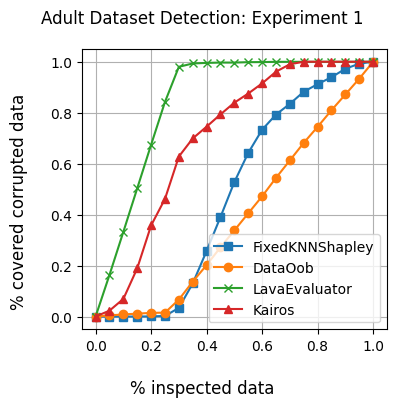

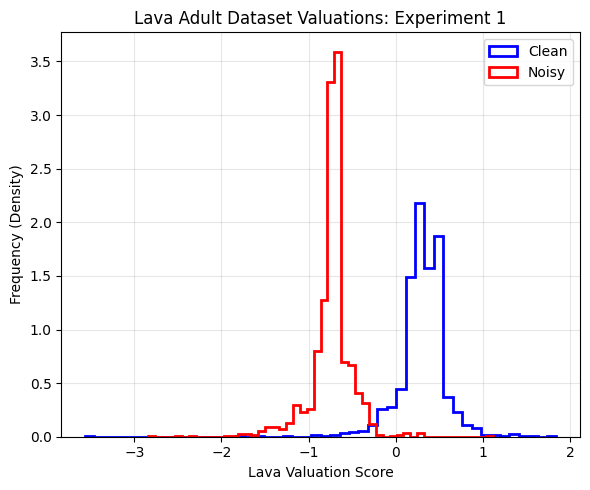

7487 3069


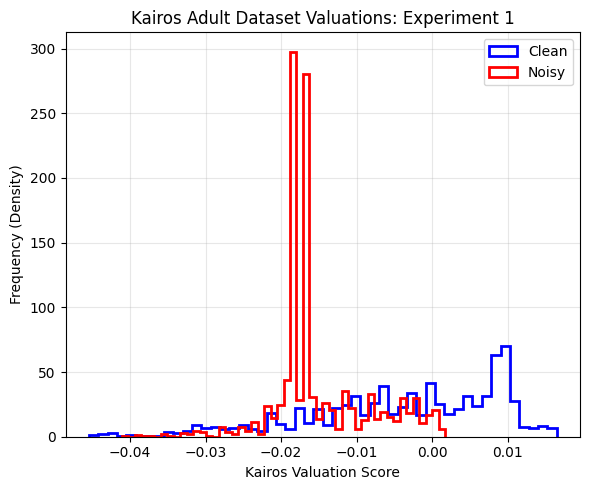

In [39]:
run_experiment(dataset_name="adult", exp_num=1, data_frac=0.35, path_to_data=PATH_TO_DATA)

### Experiment 2: Label Error Injection
SAVAGE inverts a fraction of training labels y_train.

len n train:  30162


/Users/matildagaddi/Documents/DSC180/.conda/lib/python3.9/site-packages/opendataval/dataloader/register.py:145: UserWarning: adult_experiment2 has been registered, names must be unique
  warnings.warn(f"{dataset_name} has been registered, names must be unique")
100%|██████████| 10555/10555 [00:06<00:00, 1610.39it/s]


Elapsed time FixedKNNShapley(): 0:00:08.423689


100%|██████████| 10/10 [00:01<00:00,  9.61it/s]


Elapsed time DataOob(num_models=10): 0:00:01.043609


Elapsed time LavaEvaluator(random_state=42): 0:00:02.115232
Elapsed time Kairos(sigma_feature=3.7416574954986572, lambda_weight=0.97): 0:00:01.111227
LavaEvaluator adult xperiment 2
GMM threshold: -0.0522
Accuracy: 0.6461
Precision: 0.2534
Recall: 0.2588
F1 score: 0.2561
AUC: 0.4992
----------------------------------
Kairos adult xperiment 2
GMM threshold: -0.0203
Accuracy: 0.7833
Precision: 0.5284
Recall: 0.7384
F1 score: 0.616
AUC: 0.8307
----------------------------------
8071 2485


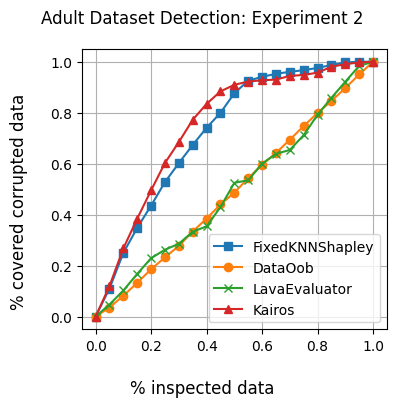

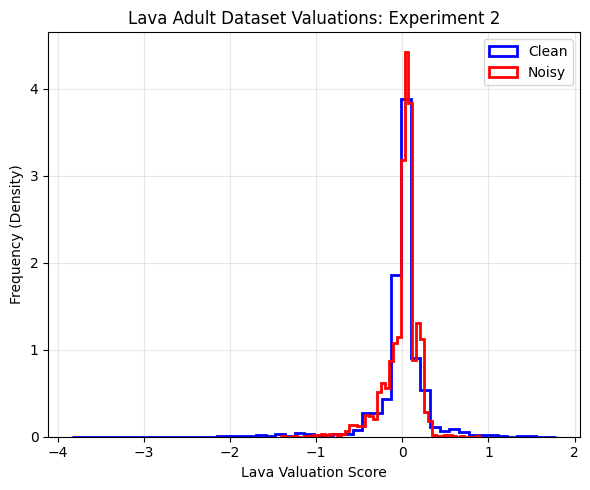

8071 2485


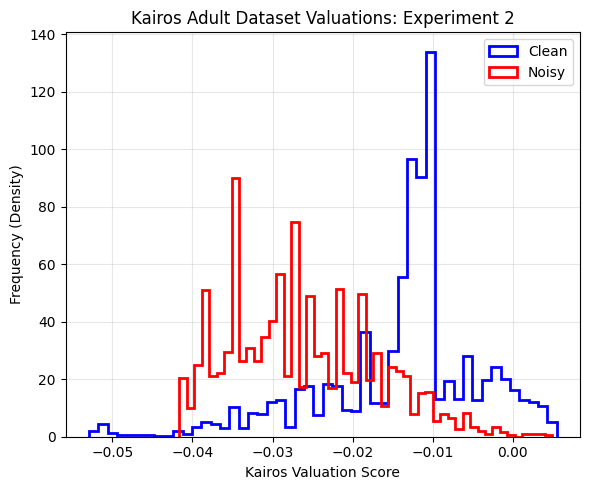

In [40]:
run_experiment(dataset_name="adult", exp_num=2, data_frac=0.35, path_to_data=PATH_TO_DATA)

### Experiment 3: Outlier Injection
SAVAGE multiplies numerical values in a feature column (in this case the martial column) by a factor (1.5).

len n train:  30162


/Users/matildagaddi/Documents/DSC180/.conda/lib/python3.9/site-packages/opendataval/dataloader/register.py:145: UserWarning: adult_experiment3 has been registered, names must be unique
  warnings.warn(f"{dataset_name} has been registered, names must be unique")
100%|██████████| 10555/10555 [00:06<00:00, 1618.43it/s]


Elapsed time FixedKNNShapley(): 0:00:08.410645


100%|██████████| 10/10 [00:01<00:00,  9.68it/s]


Elapsed time DataOob(num_models=10): 0:00:01.034924


Elapsed time LavaEvaluator(random_state=42): 0:00:02.383979
Elapsed time Kairos(sigma_feature=5.196152210235596, lambda_weight=0.97): 0:00:01.307547
LavaEvaluator adult xperiment 3
GMM threshold: -14.2352
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 score: 1.0
AUC: 1.0
----------------------------------
Kairos adult xperiment 3
GMM threshold: -0.0054
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 score: 1.0
AUC: 1.0
----------------------------------
8286 2270


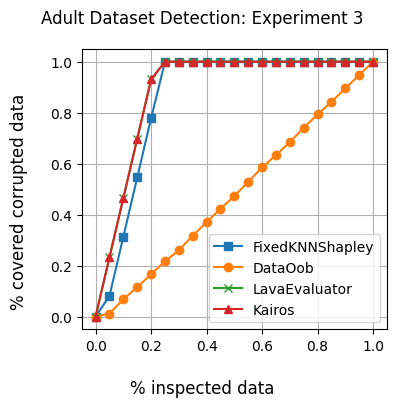

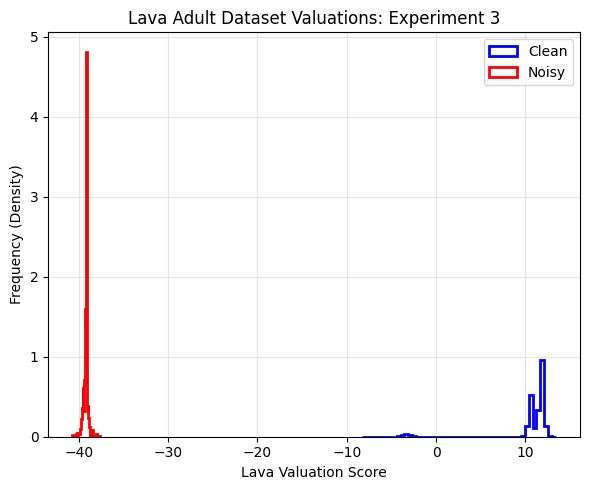

8286 2270


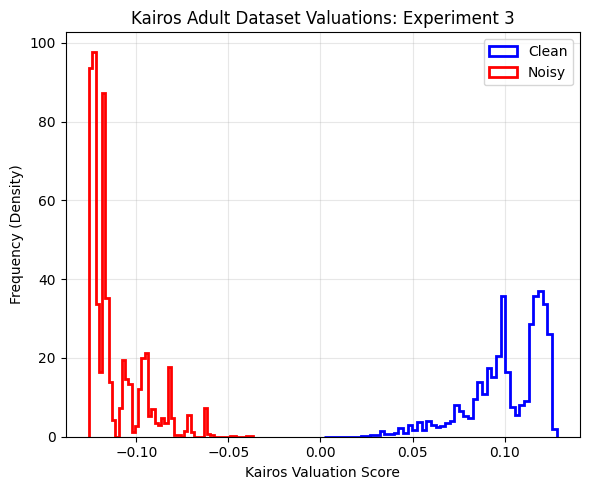

In [41]:
run_experiment(dataset_name="adult", exp_num=3, data_frac=0.35, path_to_data=PATH_TO_DATA)

### Experiment 4: Duplicate Injection
SAVAGE duplicates identified high-value rows (10% of them) and appends them to the training set, artificially inflating their influence.

len n train:  33597


/Users/matildagaddi/Documents/DSC180/.conda/lib/python3.9/site-packages/opendataval/dataloader/register.py:145: UserWarning: adult_experiment4 has been registered, names must be unique
  warnings.warn(f"{dataset_name} has been registered, names must be unique")
100%|██████████| 9406/9406 [00:04<00:00, 2077.49it/s]


Elapsed time FixedKNNShapley(): 0:00:05.922230


100%|██████████| 10/10 [00:00<00:00, 10.89it/s]


Elapsed time DataOob(num_models=10): 0:00:00.920705


Elapsed time LavaEvaluator(random_state=42): 0:00:01.831956
Elapsed time Kairos(sigma_feature=3.7416574954986572, lambda_weight=0.97): 0:00:00.513669
LavaEvaluator adult xperiment 4
GMM threshold: -0.3367
Accuracy: 0.7308
Precision: 0.6299
Recall: 0.6373
F1 score: 0.6336
AUC: 0.8096
----------------------------------
Kairos adult xperiment 4
GMM threshold: -0.0062
Accuracy: 0.7075
Precision: 0.5557
Recall: 0.9916
F1 score: 0.7123
AUC: 0.8222
----------------------------------
5972 3435


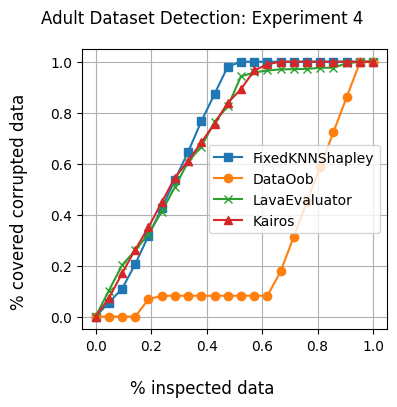

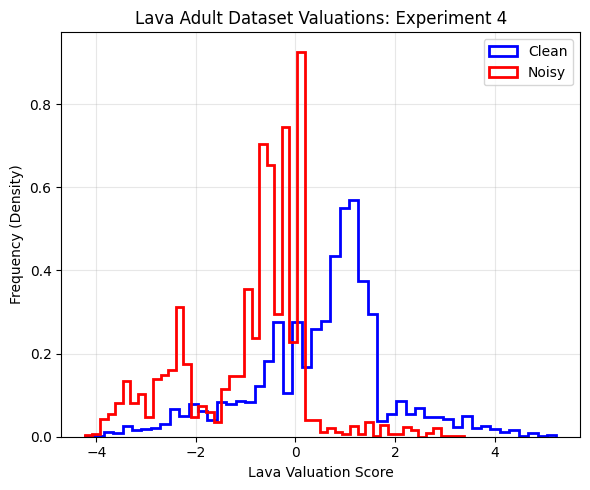

5972 3435


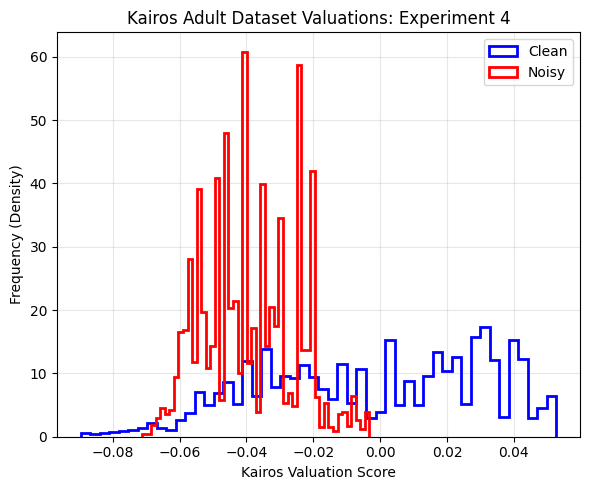

In [42]:
run_experiment(dataset_name="adult", exp_num=4, data_frac=0.28, path_to_data=PATH_TO_DATA)